In [8]:
import numpy as np 
import matplotlib.pyplot as plt 
import cv2

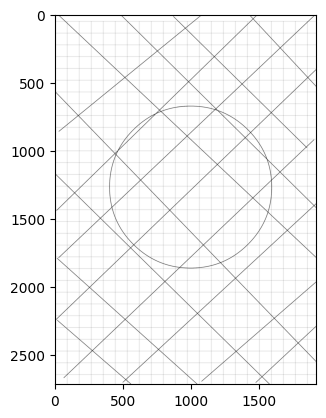

In [9]:
ruta = r'Lineas_circulo.png'
ima = cv2.imread(ruta)
ima = ima[:, :, 0]
plt.imshow(ima, cmap='gray')

In [5]:
def padding(imagen, dx):
  y, x = imagen.shape
  paddineada = np.zeros((int(y + dx/2 + 1), int(x + dx/2 + 1)))
  for j in range(y):
    for i in range(x):
      paddineada[int(j + dx/2)][int(i + dx/2)] = imagen[j][i]
  return np.array(paddineada)

# Problema 2

Suponga una aplicación criminalística en donde una huella digital está camuflajeada por una textura (líneas horizontales). Como removería las líneas y dejaría visible la huella digital?


In [ ]:
def elimina_hori(ima):
    M, N = ima.shape
    dx = 3
    hori = np.zeros_like(ima)
    # sin_hori = np.copy(ima) # para evitar modificar la original
    ima_pad = padding(ima, dx)
    # Filtro para quitar las lineas horizontales
    filtro_hori = np.array([[0, 0, 0],
                           [1, -2, 1],
                           [0, 0, 0]])
    # Recorremos la imagen aplicada
    for j in range(M):
        for i in range(N):
            # Recorremos la imagen y el filtro aplicado
            for y in range(dx):
                for x in range(dx):
                    hori[j][i] += ima_pad[j + y][i + x] * filtro_hori[y][x]
    
    return hori


In [44]:
sin_horiontales = elimina_hori(ima)

/var/folders/m0/p3fptypn0tn8sf4m4n8634bw0000gn/T/ipykernel_17209/1183024674.py:24: RuntimeWarning: overflow encountered in scalar subtract
  sin_hori[y][x] = sin_hori[y][x] - hori[y][x]


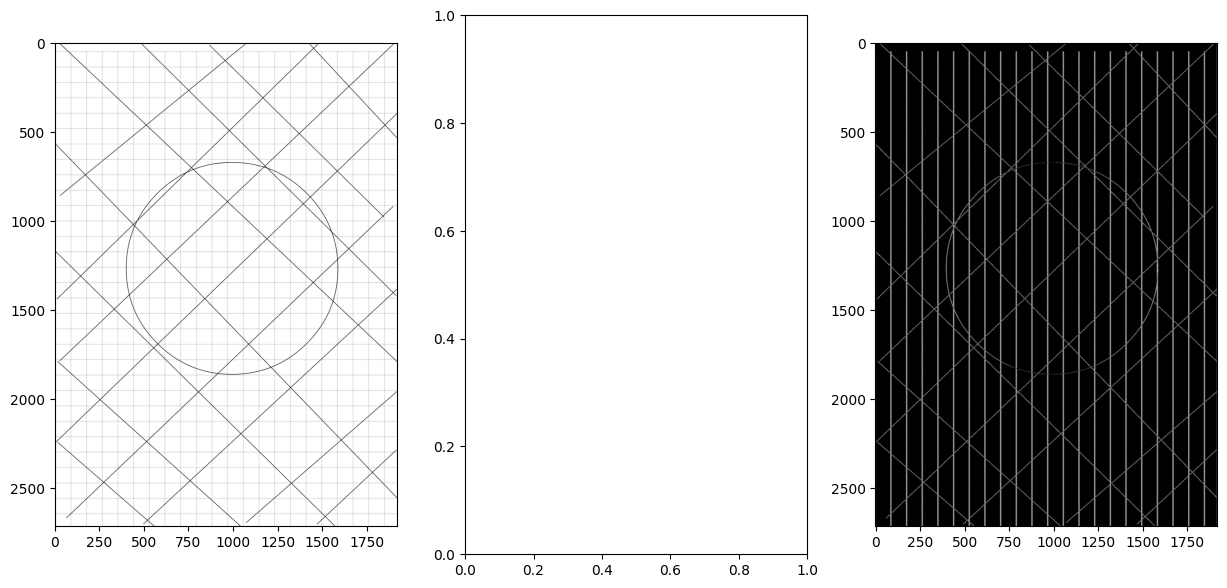

In [45]:
fig, axs = plt.subplots(1, 3, figsize = (15, 7))

axs[0].imshow(ima, cmap = 'gray')

# axs[1].imshow(sin_hori_g, cmap = 'gray')

axs[2].imshow(sin_horiontales, cmap = 'gray')

plt.show()

# Problema 3

Realice una función en python para:

Detectar únicamente las líneas a $45^{\circ}$ de una imagen digital y eliminando las demás estructuras en otra dirección.

In [50]:
def ap_filter(filter, imagen):
  y, x = imagen.shape
  sum = 0
  for j in range(y):
    for i in range(x):
      sum += (filter[j][i] * imagen[j][i])
  return sum

In [51]:
def convol(imagen, filter):
  y, x = imagen.shape
  dy, dx = filter.shape
  imagen_nueva = np.zeros((y, x))
  ima_padding = padding(imagen, dy)
  desplaza_y = int(dy/2)
  for j in range(y - desplaza_y):
    for i in range(x - desplaza_y):
      imagen_nueva[j][i] = ap_filter(filter, ima_padding[j-desplaza_y:j+desplaza_y, i-desplaza_y:i+desplaza_y])
  return np.array(imagen_nueva)

In [105]:
def operador_kirsch(imagen):
    # Definición de los 8 kernels de brújula de Kirsch
    k1 = np.array([[ 5,  5,  5], [-3,  0, -3], [-3, -3, -3]]) # Norte
    k2 = np.array([[ 5,  5, -3], [ 5,  0, -3], [-3, -3, -3]]) # Noroeste -------- Quitamos k2 (pos 1)
    k3 = np.array([[ 5, -3, -3], [ 5,  0, -3], [ 5, -3, -3]]) # Oeste 
    k4 = np.array([[-3, -3, -3], [ 5,  0, -3], [ 5,  5, -3]]) # Suroeste ------- Quitamos k4 (pos 3)
    k5 = np.array([[-3, -3, -3], [-3,  0, -3], [ 5,  5,  5]]) # Sur
    k6 = np.array([[-3, -3, -3], [-3,  0,  5], [-3,  5,  5]]) # Sureste
    k7 = np.array([[-3, -3,  5], [-3,  0,  5], [-3, -3,  5]]) # Este 
    k8 = np.array([[-3,  5,  5], [-3,  0,  5], [-3, -3, -3]]) # Noreste

    kernels = [k1, k2, k3, k4, k5, k6, k7, k8]

    # Crear un arreglo tridimensional para guardar las 8 respuestas
    y, x = imagen.shape
    respuestas = np.zeros((8, y, x))
    magnitud_kirsch = np.zeros_like(imagen).astype(float)

    # Aplicar cada kernel a la imagen
    for i, k in enumerate(kernels): # indice y valor de esa posición (filtro)
        respuestas[i] = convol(imagen, k)

    for j in range(y):
        for i in range(x):
            valores_pixel = respuestas[:, j, i]
            indice_max = np.argmax(valores_pixel)
            
            # Verificamos si la dirección es 
            if indice_max in [6, 8]: # Nos quedamos con estas
                magnitud_kirsch[j][i] = valores_pixel[indice_max]
            else: # Si no es diagonal, que NO se vea
                magnitud_kirsch[j][i] = 0 

    # Normalizar a 0-255
    min_val = np.min(magnitud_kirsch)
    max_val = np.max(magnitud_kirsch)
    magnitud_kirsch = (magnitud_kirsch - min_val) * (255.0 / (max_val - min_val))

    return magnitud_kirsch.astype(np.uint8)

In [ ]:
imagen_45 = operador_kirsch(ima)

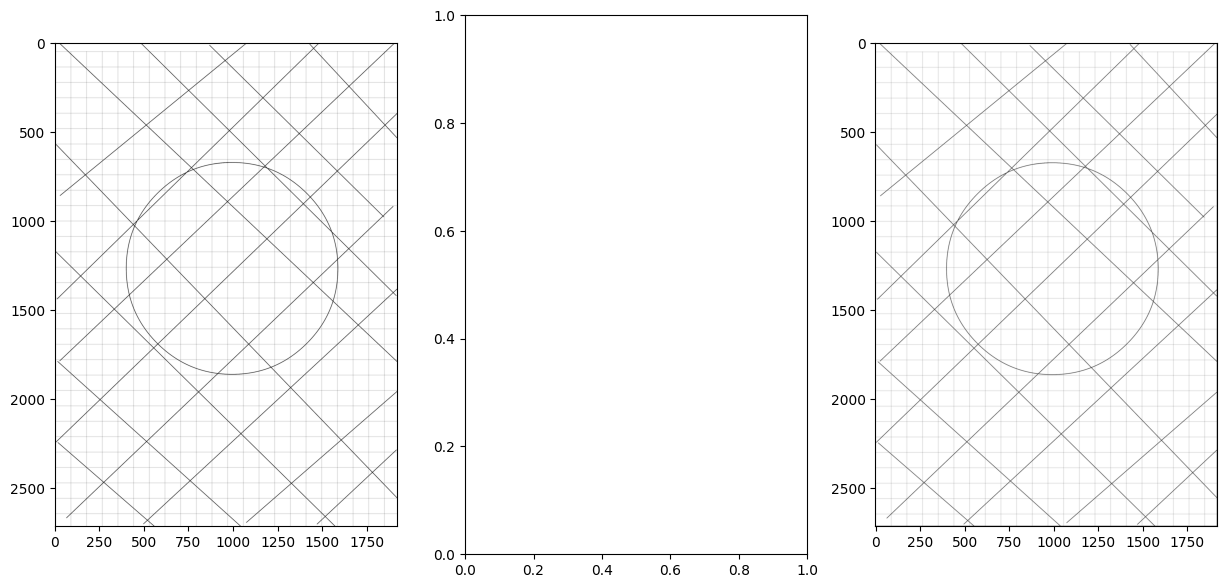

In [ ]:
fig, axs = plt.subplots(1, 3, figsize = (15, 7))

axs[0].imshow(ima, cmap = 'gray')

# axs[1].imshow(sin_hori_g, cmap = 'gray')

axs[2].imshow(imagen_45, cmap = 'gray')

plt.show()

In [74]:
arr = [0, 1, 4, 3, 4, 5]
print(np.argmax(arr))

5


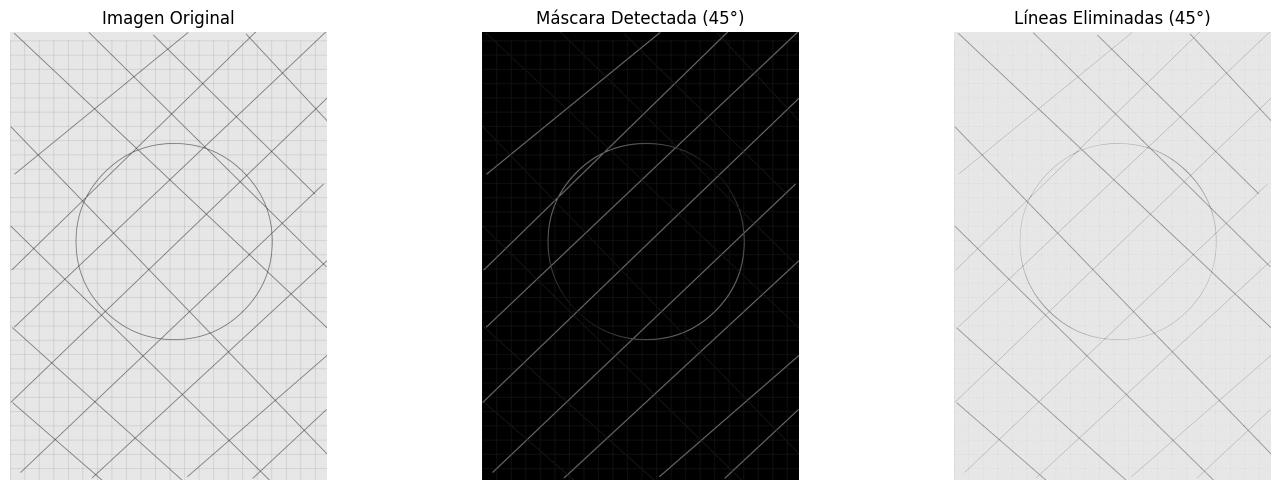

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def eliminar_lineas_kirsch(ruta_imagen, angulo=0):
    """
    Elimina líneas en una dirección específica usando filtros de Kirsch.
    Corrige automáticamente el contraste sin importar si el fondo es blanco o negro.
    """
    # 1. Cargar imagen
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"No se pudo cargar la imagen en la ruta: {ruta_imagen}")

    # 2. Detectar polaridad: ¿El fondo es mayormente claro u oscuro?
    # Si el promedio de los píxeles es mayor a 127, asumimos fondo claro (blanco)
    fondo_claro = np.mean(img) > 127
    
    # Invertir temporalmente si el fondo es claro para estandarizar la matemática
    # (Queremos que el fondo sea 0 y las líneas sean 255)
    if fondo_claro:
        img_trabajo = 255.0 - np.float32(img)
    else:
        img_trabajo = np.float32(img)

    # 3. Definir los 8 kernels de Kirsch
    kernels = {
        'N':  np.array([[ 5,  5,  5], [-3,  0, -3], [-3, -3, -3]]),
        'S':  np.array([[-3, -3, -3], [-3,  0, -3], [ 5,  5,  5]]),
        'E':  np.array([[-3, -3,  5], [-3,  0,  5], [-3, -3,  5]]),
        'W':  np.array([[ 5, -3, -3], [ 5,  0, -3], [ 5, -3, -3]]),
        'NE': np.array([[-3,  5,  5], [-3,  0,  5], [-3, -3, -3]]),
        'SW': np.array([[-3, -3, -3], [ 5,  0, -3], [ 5,  5, -3]]),
        'NW': np.array([[ 5,  5, -3], [ 5,  0, -3], [-3, -3, -3]]),
        'SE': np.array([[-3, -3, -3], [-3,  0,  5], [-3,  5,  5]])
    }

    # 4. Mapear el ángulo de la línea
    mapa_angulos = {
        0:   ['N', 'S'],     # Línea horizontal
        90:  ['E', 'W'],     # Línea vertical
        45:  ['NW', 'SE'],   # Línea diagonal (/)
        -45: ['NE', 'SW'],   # Línea diagonal (\)
        135: ['NE', 'SW']    # Equivalente a -45°
    }

    if angulo not in mapa_angulos:
        raise ValueError("Ángulo no soportado. Usa 0, 45, 90, o -45.")

    direcciones_objetivo = mapa_angulos[angulo]
    borde_max = np.zeros_like(img_trabajo)

    # 5. Aplicar convolución direccional
    for dir_key in direcciones_objetivo:
        kernel = kernels[dir_key]
        filtrado = cv2.filter2D(img_trabajo, cv2.CV_32F, kernel)
        filtrado = np.maximum(filtrado, 0) # Quedarse solo con respuestas positivas
        borde_max = np.maximum(borde_max, filtrado)

    # Normalizar la máscara de bordes para que vaya de 0 a 255
    if np.max(borde_max) > 0:
        borde_max = (borde_max / np.max(borde_max)) * 255.0

    # 6. Restar la máscara de la imagen de trabajo (borrando las líneas)
    img_procesada = np.clip(img_trabajo - borde_max, 0, 255)

    # 7. Regresar la imagen a su color original (si el fondo era claro)
    if fondo_claro:
        img_final = 255.0 - img_procesada
    else:
        img_final = img_procesada

    img_final = img_final.astype(np.uint8)

    # 8. Graficar resultados
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title('Imagen Original')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title(f'Máscara Detectada ({angulo}°)')
    # Mostramos la máscara que se restó internamente
    plt.imshow(borde_max.astype(np.uint8), cmap='gray', vmin=0, vmax=255) 
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f'Líneas Eliminadas ({angulo}°)')
    plt.imshow(img_final, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Tu llamada original
# ruta = 'Copia de Casa con bordes.jpg' # Ajusta el nombre de la variable de tu entorno si es necesario
eliminar_lineas_kirsch(ruta, angulo=45)